# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Sabrina Ganeshswara Putri]
- **Email:** [Sabrinaganeshswara.23036@mhs.unesa.ac.id]
- **ID Dicoding:** [Sabrina Ganeshswara Putri]

## Menentukan Pertanyaan Bisnis

- Bagaimana tren jumlah penyewaan sepeda dari tahun 2011 ke 2012?
- Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?
- Bagaimana perbedaan jumlah penyewaan antara hari kerja dan akhir pekan?
- Bagaimana perbedaan pola penyewaan sepeda antara pengguna casual dan registered berdasarkan waktu?

## Import Semua Packages/Library yang Digunakan

In [535]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [536]:
day_df = pd.read_csv('day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset berisi informasi penyewaan sepeda per hari dengan berbagai fitur seperti cuaca, musim, dan tipe hari.
- Terdapat dua jenis pengguna, yaitu casual dan registered, dengan total penyewaan (cnt) sebagai target utama.
- Variabel seperti cuaca (weathersit), suhu (temp), dan hari kerja (workingday) berpotensi mempengaruhi jumlah penyewaan.

In [537]:
hour_df = pd.read_csv('hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset berisi data penyewaan sepeda per jam dengan tambahan variabel waktu seperti jam (hr).
- Jumlah penyewaan per jam (cnt) cenderung masih rendah pada jam-jam awal (dini hari).
- Dataset ini memungkinkan analisis pola penyewaan berdasarkan waktu yang lebih detail dibandingkan data harian.

### Assessing Data

1. Menilai Data `day_df`

In [538]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [539]:
print("Jumlah duplikasi:", day_df.duplicated().sum())
day_df.isna().sum()

Jumlah duplikasi: 0


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [540]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Dataset memiliki 731 baris dan 16 kolom tanpa adanya missing value.
- Tidak ditemukan data duplikat pada dataset.
- Tipe data sebagian besar sudah sesuai, namun kolom dteday masih bertipe object dan perlu diubah menjadi datetime.
- Nilai pada kolom numerik seperti cnt, casual, dan registered menunjukkan variasi yang cukup besar, yang mengindikasikan adanya perbedaan tingkat penyewaan yang signifikan.

**2. Menilai Data `hour_df`**

In [541]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [542]:
print("Jumlah duplikasi:", hour_df.duplicated().sum())
hour_df.isna().sum()

Jumlah duplikasi: 0


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [543]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**insight:**
- Dataset terdiri dari 17.379 baris dan 17 kolom tanpa adanya missing value.
- Tidak ditemukan data duplikat pada dataset.
- Dataset memiliki variabel tambahan yaitu jam (hr) yang memungkinkan analisis pola penyewaan secara lebih detail.

### Cleaning Data

1. Cleaning data `day_df`

- **Ubah tipe data dteday → datetime**

    Kolom dteday diubah menjadi tipe data datetime agar data dapat dianalisis berdasarkan waktu secara lebih efektif.

In [544]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

- **Mengubah kode numerik menjadi label deskriptif**

    biar data lebih gampang dibaca dan dimengerti

In [545]:
# Season
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}

# Year
yr_map = {0: '2011',1: '2012'}

# Month
mnth_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

# Weekday
weekday_map = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed',4: 'Thu', 5: 'Fri', 6: 'Sat'}

# Binary (holiday & workingday)
binary_map = {0: 'No',1: 'Yes'}  # No : Weekends # Yes : Hari Kerja

# Weather
weathersit_map = {1: 'Clear',2: 'Mist/Cloudy',3: 'Light Rain/Snow',4: 'Heavy Rain/Snow'}

In [546]:
day_df['season'] = day_df['season'].map(season_map)
day_df['yr'] = day_df['yr'].map(yr_map)
day_df['mnth'] = day_df['mnth'].map(mnth_map)
day_df['weekday'] = day_df['weekday'].map(weekday_map)
day_df['holiday'] = day_df['holiday'].map(binary_map)
day_df['workingday'] = day_df['workingday'].map(binary_map)
day_df['weathersit'] = day_df['weathersit'].map(weathersit_map)

- **Mengubah kolom-kolom jadi tipe “kategori” (category)**

    Mengubah kolom menjadi tipe category bertujuan agar data yang berupa kode angka dapat diperlakukan sebagai kategori, bukan nilai numerik. Hal ini membuat analisis dan visualisasi menjadi lebih jelas serta menghindari kesalahan interpretasi.

In [547]:
categorical_cols = ['season', 'yr', 'mnth','weekday', 'weathersit','holiday', 'workingday']
for col in categorical_cols:
    day_df[col] = day_df[col].astype('category')

In [548]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    category      
 3   yr          731 non-null    category      
 4   mnth        731 non-null    category      
 5   holiday     731 non-null    category      
 6   weekday     731 non-null    category      
 7   workingday  731 non-null    category      
 8   weathersit  731 non-null    category      
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: category(7), datetime64

In [549]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,Jan,No,Sat,No,Mist/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,Jan,No,Sun,No,Mist/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,Jan,No,Mon,Yes,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,Jan,No,Tue,Yes,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,Jan,No,Wed,Yes,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- tidak ditemuakn missing values dan duplicate data sehingga lebih difokuskan pada penyesuaian data
- Beberapa kolom dalam dataset merupakan kategori yang direpresentasikan dalam bentuk angka.
- Dilakukan perubahan ke bentuk label agar data lebih mudah dipahami dan dianalisis. Penggunaan label membantu menghindari kesalahan dalam memahami arti kategori, terutama bagi pengguna non-teknis.

2. Cleaning data `hour_df`

- **Ubah tipe data dteday → datetime**

    Kolom dteday diubah menjadi tipe data datetime agar data dapat dianalisis berdasarkan waktu secara lebih efektif.

In [550]:
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

- **Mengubah kode numerik menjadi label deskriptif**

    biar data lebih gampang dibaca dan dimengerti

In [551]:
# mapping
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
yr_map = {0: '2011', 1: '2012'}
mnth_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
weekday_map = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}
binary_map = {0: 'No', 1: 'Yes'}
weathersit_map = {
    1: 'Clear',
    2: 'Mist/Cloudy',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}

# mapping sekali saja
hour_df['season'] = hour_df['season'].map(season_map)
hour_df['yr'] = hour_df['yr'].map(yr_map)
hour_df['mnth'] = hour_df['mnth'].map(mnth_map)
hour_df['weekday'] = hour_df['weekday'].map(weekday_map)
hour_df['holiday'] = hour_df['holiday'].map(binary_map)
hour_df['workingday'] = hour_df['workingday'].map(binary_map)
hour_df['weathersit'] = hour_df['weathersit'].map(weathersit_map)

- **Mengubah kolom-kolom jadi tipe “kategori” (category)**

    Mengubah kolom menjadi tipe category bertujuan agar data yang berupa kode angka dapat diperlakukan sebagai kategori, bukan nilai numerik. Hal ini membuat analisis dan visualisasi menjadi lebih jelas serta menghindari kesalahan interpretasi.

In [552]:
categorical_cols = ['season', 'yr', 'mnth', 'hr','weekday', 'weathersit','holiday', 'workingday']
for col in categorical_cols:
    hour_df[col] = hour_df[col].astype('category')

In [553]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  category      
 3   yr          17379 non-null  category      
 4   mnth        17379 non-null  category      
 5   hr          17379 non-null  category      
 6   holiday     17379 non-null  category      
 7   weekday     17379 non-null  category      
 8   workingday  17379 non-null  category      
 9   weathersit  17379 non-null  category      
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

In [554]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,Jan,0,No,Sat,No,Clear,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,Jan,1,No,Sat,No,Clear,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,Jan,2,No,Sat,No,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,Jan,3,No,Sat,No,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,Jan,4,No,Sat,No,Clear,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**

Tidak ditemukan missing value maupun data duplikat pada hour_df, sehingga proses cleaning difokuskan pada penyesuaian tipe data. Perubahan ini dilakukan agar data lebih mudah dipahami dan siap digunakan untuk analisis pola penyewaan berdasarkan waktu secara lebih detail.

In [555]:
day_df.to_csv('day_clean.csv', index=False)

In [556]:
hour_df.to_csv('hour_clean.csv', index=False)

## Exploratory Data Analysis (EDA)

### Explore `day_df`

In [557]:
day_df.sample(5)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
17,18,2011-01-18,Spring,2011,Jan,No,Tue,Yes,Mist/Cloudy,0.216667,0.232333,0.861667,0.146775,9,674,683
512,513,2012-05-27,Summer,2012,May,No,Sun,No,Clear,0.690000,0.641425,0.697083,0.215171,3283,3308,6591
319,320,2011-11-16,Winter,2011,Nov,No,Wed,Yes,Light Rain/Snow,0.456667,0.451988,0.930000,0.136829,145,1672,1817
533,534,2012-06-17,Summer,2012,Jun,No,Sun,No,Clear,0.592500,0.571975,0.598750,0.144904,2634,4344,6978
673,674,2012-11-04,Winter,2012,Nov,No,Sun,No,Clear,0.325833,0.329538,0.532917,0.179108,1201,3906,5107


In [558]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731,731,731,731,731,731,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,NaN,4,2,12,2,7,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,2012,Aug,No,Mon,Yes,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,188,366,62,710,105,500,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,2012-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:** Data menunjukkan variasi jumlah penyewaan sepeda yang cukup besar antar hari.

In [559]:
day_df['cnt'].describe()

,cnt
count,731.000000
mean,4504.348837
std,1937.211452
min,22.000000
25%,3152.000000
50%,4548.000000
75%,5956.000000
max,8714.000000


**Insight:** jumlah penyewaan sepeda per hari memiliki variasi yang cukup besar, dengan rata-rata sekitar 4504 sepeda dan dapat mencapai hingga 8714 sepeda pada hari tertentu.

In [560]:
day_df.groupby(by="season").agg({"cnt": ["mean", "max", "min"]})

/tmp/ipykernel_3468/2574971938.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby(by="season").agg({"cnt": ["mean", "max", "min"]})


cnt            
               mean   max   min
season                         
Fall    5644.303191  8714  1115
Spring  2604.132597  7836   431
Summer  4992.331522  8362   795
Winter  4728.162921  8555    22

**Insight:** Penyewaan sepeda berbeda di setiap musim, menunjukkan adanya pengaruh musim terhadap penggunaan sepeda.

In [561]:
day_df.groupby(by="mnth").agg({"cnt": ["mean", "max", "min"]})

/tmp/ipykernel_3468/2544911575.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby(by="mnth").agg({"cnt": ["mean", "max", "min"]})


cnt            
             mean   max   min
mnth                         
Apr   4484.900000  7460   795
Aug   5664.419355  7865  1115
Dec   3403.806452  6606   441
Feb   2655.298246  5062  1005
Jan   2176.338710  4521   431
Jul   5563.677419  8173  3285
Jun   5772.366667  8120  3767
Mar   3692.258065  8362   605
May   5349.774194  8294  2633
Nov   4247.183333  6852  1495
Oct   5199.225806  8156    22
Sep   5766.516667  8714  1842

**Insight:** Rata-rata penyewaan sepeda bervariasi tiap bulan, menandakan adanya pola musiman.

In [562]:
day_df.groupby(by="workingday").agg({"cnt": ["mean", "max", "min"]})

/tmp/ipykernel_3468/1047576006.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby(by="workingday").agg({"cnt": ["mean", "max", "min"]})


cnt           
                   mean   max  min
workingday                        
No          4330.168831  8714  605
Yes         4584.820000  8362   22

**Insight**: Terdapat perbedaan penggunaan sepeda antara hari kerja dan hari libur.

In [563]:
day_df.groupby(by="weathersit").agg({"cnt": ["mean" , "max", "min"]})

/tmp/ipykernel_3468/216522321.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby(by="weathersit").agg({"cnt": ["mean" , "max", "min"]})


cnt           
                        mean   max  min
weathersit                             
Clear            4876.786177  8714  431
Light Rain/Snow  1803.285714  4639   22
Mist/Cloudy      4035.862348  8362  605

**Insight:** Semakin buruk kondisi cuaca, semakin rendah jumlah penyewaan sepeda.

In [564]:
day_df.groupby(by="weekday").agg({"cnt": ["mean", "max", "min"]})

/tmp/ipykernel_3468/2323734439.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby(by="weekday").agg({"cnt": ["mean", "max", "min"]})


cnt            
                mean   max   min
weekday                         
Fri      4690.288462  8362  1167
Mon      4338.123810  7525    22
Sat      4550.542857  8714   627
Sun      4228.828571  8227   605
Thu      4667.259615  7804   431
Tue      4510.663462  7767   683
Wed      4548.538462  8173   441

**insight**: Penggunaan sepeda berbeda pada setiap hari dalam seminggu.

### Explore `hour_df`

In [565]:
hour_df.sample(5)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
7539,7540,2011-11-15,Winter,2011,Nov,18,No,Tue,Yes,Mist/Cloudy,0.50,0.4848,0.72,0.2836,27,414,441
15739,15740,2012-10-23,Winter,2012,Oct,0,No,Tue,Yes,Clear,0.46,0.4545,0.88,0.1642,5,32,37
1208,1209,2011-02-23,Spring,2011,Feb,10,No,Wed,Yes,Clear,0.20,0.2576,0.40,0.0000,4,47,51
15078,15079,2012-09-25,Winter,2012,Sep,11,No,Tue,Yes,Clear,0.60,0.6212,0.46,0.2985,63,155,218
9660,9661,2012-02-12,Spring,2012,Feb,11,No,Sun,No,Clear,0.12,0.1061,0.42,0.2985,3,121,124


**Insight:** Dataset sangat kaya fitur, sehingga memungkinkan analisis mendalam dari berbagai faktor yang memengaruhi penyewaan sepeda.

In [566]:
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379,17379,17379,17379.0,17379,17379,17379,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4,2,12,24.0,2,7,2,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,2012,May,16.0,No,Sat,Yes,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496,8734,1488,730.0,16879,2512,11865,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**insight:** Dataset mencakup 2 tahun penuh, cukup untuk melihat pola musiman dan tren.

In [567]:
hour_df['cnt'].describe()

,cnt
count,17379.000000
mean,189.463088
std,181.387599
min,1.000000
25%,40.000000
50%,142.000000
75%,281.000000
max,977.000000


**Insight:** Jumlah penyewaan sepeda per jam memiliki variasi yang cukup besar, dengan rata-rata sekitar 189 sepeda, namun dapat meningkat hingga 977 sepeda pada jam tertentu.

In [568]:
hour_df.groupby(by="hr").agg({"cnt": ["mean", "max", "min"]})

/tmp/ipykernel_3468/3212259336.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hour_df.groupby(by="hr").agg({"cnt": ["mean", "max", "min"]})


cnt         
          mean  max min
hr                     
0    53.898072  283   2
1    33.375691  168   1
2    22.869930  132   1
3    11.727403   79   1
4     6.352941   28   1
5    19.889819   66   1
6    76.044138  213   1
7   212.064649  596   1
8   359.011004  839   5
9   219.309491  426  14
10  173.668501  539   8
11  208.143054  663  10
12  253.315934  776   3
13  253.661180  760  11
14  240.949246  750  12
15  251.233196  750   7
16  311.983562  783  11
17  461.452055  976  15
18  425.510989  977  23
19  311.523352  743  11
20  226.030220  567  11
21  172.314560  584   6
22  131.335165  502   9
23   87.831044  256   2

**Insight:** Penyewaan sepeda meningkat pada jam-jam tertentu, terutama pagi dan sore hari, yang menunjukkan adanya pola jam sibuk.

In [569]:
hour_df.groupby(by="weathersit").agg({"cnt": ["mean", "max", "min"]})

/tmp/ipykernel_3468/427113810.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hour_df.groupby(by="weathersit").agg({"cnt": ["mean", "max", "min"]})


cnt         
                       mean  max min
weathersit                          
Clear            204.869272  977   1
Heavy Rain/Snow   74.333333  164  23
Light Rain/Snow  111.579281  891   1
Mist/Cloudy      175.165493  957   1

**Insight:** Kondisi cuaca mempengaruhi jumlah penyewaan sepeda, di mana cuaca buruk menyebabkan penurunan penggunaan.

In [570]:
hour_df.groupby(by="workingday").agg({"cnt": ["mean", "max", "min"]})

/tmp/ipykernel_3468/321280378.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hour_df.groupby(by="workingday").agg({"cnt": ["mean", "max", "min"]})


cnt         
                  mean  max min
workingday                     
No          181.405332  783   1
Yes         193.207754  977   1

**Insight:** Terdapat perbedaan penggunaan sepeda antara hari kerja dan hari libur, yang menunjukkan pola aktivitas pengguna yang berbeda.

In [571]:
hour_df.groupby(by="season").agg({"cnt": ["mean", "max", "min"]})

/tmp/ipykernel_3468/339396554.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hour_df.groupby(by="season").agg({"cnt": ["mean", "max", "min"]})


cnt         
              mean  max min
season                     
Fall    236.016237  977   1
Spring  111.114569  801   1
Summer  208.344069  957   1
Winter  198.868856  967   1

**insight:** Penyewaan sepeda berbeda pada setiap musim, menunjukkan adanya pengaruh faktor musiman terhadap penggunaan.

In [572]:
hour_df.groupby(by="weekday").agg({"cnt": ["mean", "max", "min"]})

/tmp/ipykernel_3468/880086705.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hour_df.groupby(by="weekday").agg({"cnt": ["mean", "max", "min"]})


cnt         
               mean  max min
weekday                     
Fri      196.135907  957   1
Mon      183.744655  968   1
Sat      190.209793  783   1
Sun      177.468825  776   1
Thu      196.436665  976   1
Tue      191.238891  970   1
Wed      191.130505  977   1

**Insight:** Penggunaan sepeda bervariasi pada setiap hari dalam seminggu, menunjukkan adanya pola penggunaan harian.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

**Bagaimana tren jumlah penyewaan sepeda dari tahun 2011 ke 2012?**

In [573]:
# Membuat kolom year/tahun
day_df['year'] = day_df['dteday'].dt.year

**Insight:** Data diubah ke bulanan karena ingin melihat trend umum yang lebih jelas, bukan fluktuasi harian yang acak.

In [574]:
# memfilter data di tahun 2011
day_2011 = day_df[day_df['year'] == 2011]
day_2011[['dteday', 'cnt']].head()

,dteday,cnt
0,2011-01-01,985
1,2011-01-02,801
2,2011-01-03,1349
3,2011-01-04,1562
4,2011-01-05,1600


In [575]:
# memfilter data ditahun 2012
day_2012 = day_df[day_df['year'] == 2012]
day_2012[['dteday', 'cnt']].head()

,dteday,cnt
365,2012-01-01,2294
366,2012-01-02,1951
367,2012-01-03,2236
368,2012-01-04,2368
369,2012-01-05,3272


In [576]:
# membuat kolom month/bulan
day_df['month'] = day_df['dteday'].dt.month
# menghitung rata-rata pertahun dan perbulan
trend_year = day_df.groupby(['year', 'month'])['cnt'].mean().reset_index()
trend_year

,year,month,cnt
0,2011,1,1231.903226
1,2011,2,1721.964286
2,2011,3,2065.967742
3,2011,4,3162.333333
4,2011,5,4381.322581
5,2011,6,4783.733333
6,2011,7,4559.387097
7,2011,8,4409.387097
8,2011,9,4247.266667
9,2011,10,3984.225806


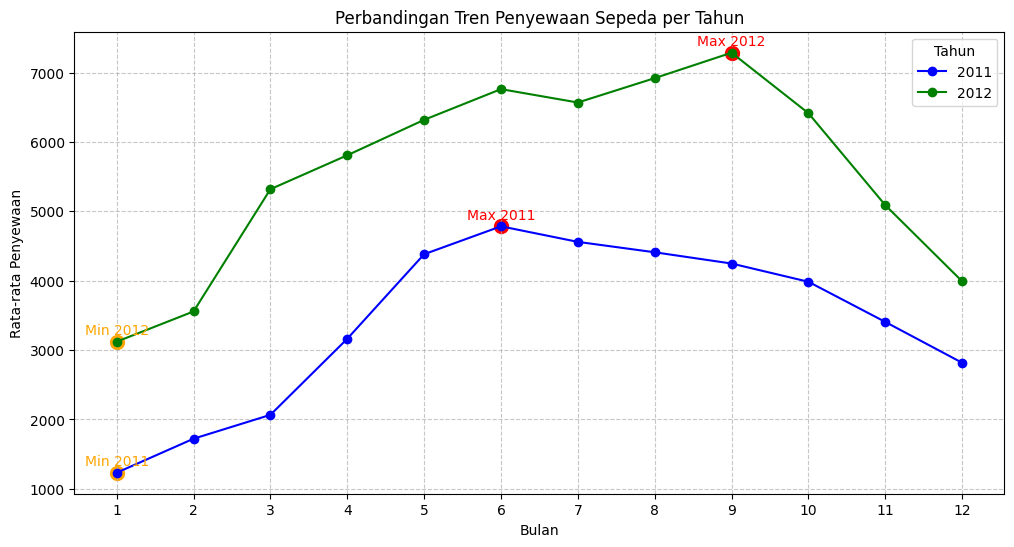

In [577]:
# memvisualisasikan
plt.figure(figsize=(12,6))

colors = {2011: 'blue', 2012: 'green'}

for year in trend_year['year'].unique():
    data = trend_year[trend_year['year'] == year]

    # plot garis
    plt.plot(data['month'], data['cnt'], marker='o',
             color=colors[year], label=str(year))

    # cari max & min
    max_row = data.loc[data['cnt'].idxmax()]
    min_row = data.loc[data['cnt'].idxmin()]

    # plot titik max
    plt.scatter(max_row['month'], max_row['cnt'],
                color='red', s=100)
    plt.text(max_row['month'], max_row['cnt']+100,
             f'Max {year}', ha='center', color='red')

    # plot titik min
    plt.scatter(min_row['month'], min_row['cnt'],
                color='orange', s=100)
    plt.text(min_row['month'], min_row['cnt']+100,
             f'Min {year}', ha='center', color='orange')

# tampilan
plt.title('Perbandingan Tren Penyewaan Sepeda per Tahun')
plt.xlabel('Bulan')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(range(1,13))
plt.legend(title='Tahun')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

**Insight:** Tren penyewaan sepeda menunjukkan pola yang cenderung meningkat dari tahun 2011 ke 2012, dengan puncak penggunaan terjadi pada pertengahan tahun dan penurunan di awal serta akhir tahun. Hal ini menunjukkan adanya pola musiman dalam penggunaan sepeda.

### Pertanyaan 2:

**Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?**

In [578]:
# Menghitung rata-rata penyewaan berdasarkan cuaca
weather_trend = day_df.groupby(by="weathersit")["cnt"].mean().sort_values()
weather_trend

/tmp/ipykernel_3468/42965694.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weather_trend = day_df.groupby(by="weathersit")["cnt"].mean().sort_values()


,cnt
weathersit,
Light Rain/Snow,1803.285714
Mist/Cloudy,4035.862348
Clear,4876.786177


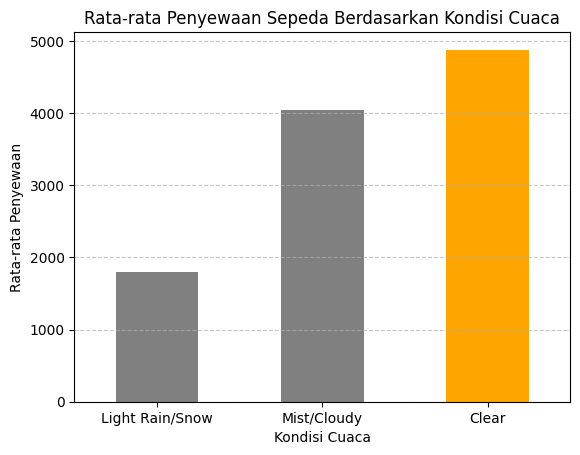

In [579]:
# memvisualisasi data
colors = ['gray' if x != weather_trend.max() else 'orange' for x in weather_trend]

weather_trend.plot(kind='bar', color=colors)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**Insight:**
Kondisi cuaca memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda, di mana penyewaan tertinggi terjadi saat cuaca cerah dan menurun secara bertahap pada kondisi cuaca yang lebih buruk seperti mendung dan hujan.

### Pertanyaan 3:

**Bagaimana perbedaan jumlah penyewaan antara hari kerja dan Libur?**

In [580]:
workingday_trend = day_df.groupby("workingday")["cnt"].mean() # 0 = hari libur/weekend # 1 = hari kerja/ weekdays
workingday_trend

/tmp/ipykernel_3468/3786125308.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  workingday_trend = day_df.groupby("workingday")["cnt"].mean() # 0 = hari libur/weekend # 1 = hari kerja/ weekdays


,cnt
workingday,
No,4330.168831
Yes,4584.820000


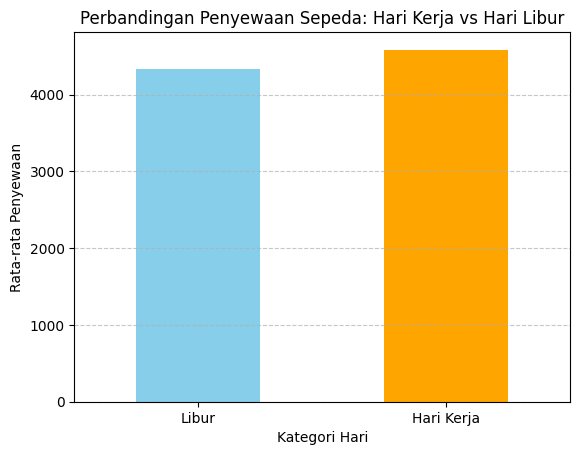

In [581]:
#visualisasi plot gambar
workingday_trend.plot(kind='bar', color=['skyblue', 'orange'])

plt.title('Perbandingan Penyewaan Sepeda: Hari Kerja vs Hari Libur')
plt.xlabel('Kategori Hari')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks([0,1], ['Libur', 'Hari Kerja'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**Insight:** Terdapat perbedaan jumlah penyewaan sepeda antara hari kerja dan hari libur, di mana penyewaan sepeda cenderung lebih tinggi pada hari kerja dibandingkan hari libur.

### Pertanyaan 4:

**Bagaimana perbedaan pola penyewaan sepeda antara pengguna casual dan registered berdasarkan waktu?**

In [582]:
hour_trend = hour_df.groupby('hr')[['casual', 'registered']].mean()
hour_trend

/tmp/ipykernel_3468/526370417.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hour_trend = hour_df.groupby('hr')[['casual', 'registered']].mean()


,casual,registered
hr,,
0,10.158402,43.739669
1,6.504144,26.871547
2,4.772028,18.097902
3,2.715925,9.011478
4,1.253945,5.098996
5,1.411437,18.478382
6,4.161379,71.882759
7,11.055021,201.009629
8,21.679505,337.331499


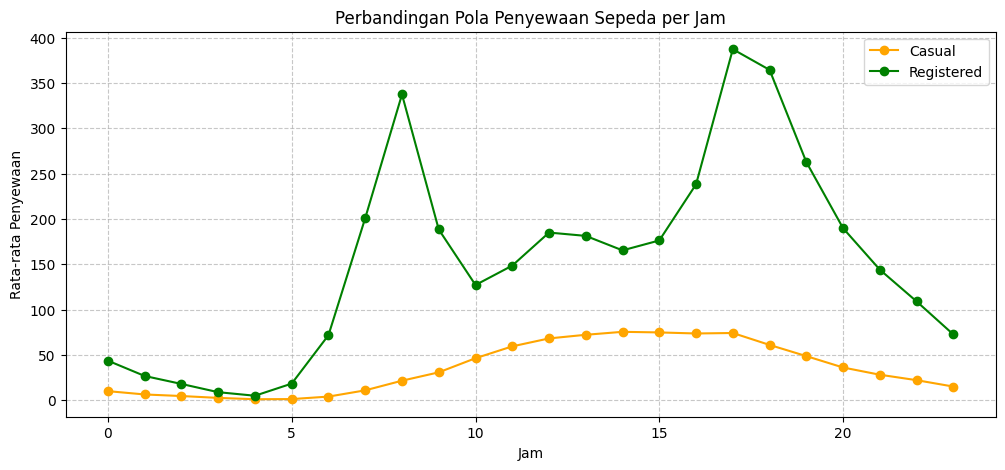

In [583]:
plt.figure(figsize=(12,5))

plt.plot(hour_trend.index, hour_trend['casual'],
         label='Casual', marker='o', color='orange')

plt.plot(hour_trend.index, hour_trend['registered'],
         label='Registered', marker='o', color='green')

plt.title('Perbandingan Pola Penyewaan Sepeda per Jam')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

**Insight:** Pengguna registered menunjukkan pola penggunaan sepeda yang tinggi pada jam sibuk pagi dan sore hari, sedangkan pengguna casual cenderung menggunakan sepeda pada siang hingga sore hari. Hal ini menunjukkan bahwa pengguna registered lebih banyak menggunakan sepeda untuk aktivitas rutin seperti bekerja, sementara pengguna casual lebih untuk rekreasi.

## Analisis Lanjutan (Opsional)

**Clustering**

Clustering dipilih karena dapat mengelompokkan data berdasarkan pola penggunaan tanpa memerlukan algoritma machine learning. Metode manual **grouping** digunakan karena dataset tidak memiliki informasi pelanggan atau lokasi, sehingga pengelompokan dilakukan berdasarkan pemahaman domain, yaitu waktu penggunaan. Waktu dipilih sebagai dasar pengelompokan karena merupakan faktor utama yang mempengaruhi jumlah penyewaan sepeda, terutama dalam membedakan antara jam sibuk dan non-sibuk.

In [584]:
#membuat beberapa kategori yang ingin dianalisis
def categorize_hour(hr):
    if 6 <= hr <= 9:
        return 'Morning Peak'
    elif 16 <= hr <= 19:
        return 'Evening Peak'
    elif 10 <= hr <= 15:
        return 'Afternoon'
    else:
        return 'Off Hours'

hour_df['time_group'] = hour_df['hr'].apply(categorize_hour)

In [585]:
time_group_trend = hour_df.groupby('time_group')['cnt'].mean().sort_values()
time_group_trend

,cnt
time_group,
Off Hours,77.359071
Morning Peak,216.704061
Afternoon,230.192493
Evening Peak,377.629973


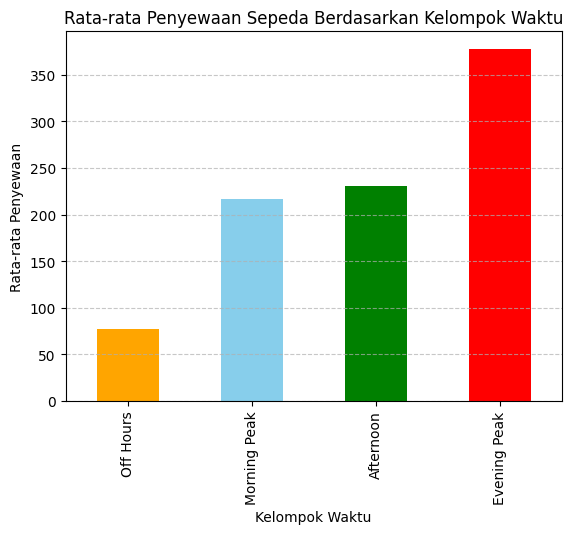

In [586]:
time_group_trend.plot(kind='bar', color=['orange', 'skyblue', 'green', 'red'])

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kelompok Waktu')
plt.xlabel('Kelompok Waktu')
plt.ylabel('Rata-rata Penyewaan')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**Insight:**

  Hasil clustering berdasarkan waktu menunjukkan bahwa penyewaan sepeda paling tinggi terjadi pada jam sibuk, yaitu pagi dan sore hari. Sementara itu, penyewaan paling rendah terjadi pada waktu di luar jam sibuk (non-peak hours). Hal ini menunjukkan bahwa sepeda banyak digunakan untuk aktivitas rutin seperti bekerja atau bersekolah.

## Conclusion

- Conclution pertanyaan 1 : **Bagaimana tren jumlah penyewaan sepeda dari tahun 2011 ke 2012?**

  Dari grafik pada visualisasi dapat dilihat bahwa, jumlah penyewaan sepeda dari tahun 2011 ke 2012 mengalami peningkatan yang cukup jelas. Hampir di semua bulan, angka penyewaan di tahun 2012 selalu lebih tinggi dibanding 2011. Polanya juga mirip di kedua tahun, yaitu naik dari awal tahun, mencapai puncak di pertengahan tahun (sekitar Juni–September), lalu turun lagi menjelang akhir tahun. Perbedaannya, di tahun 2012 kenaikannya lebih tinggi dan puncaknya juga lebih besar dibanding 2011. Ini menunjukkan bahwa minat atau penggunaan layanan penyewaan sepeda semakin meningkat dari tahun ke tahun.

- Conclution pertanyaan 2 : **Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?**

  Dari grafik tersebut terlihat jelas kalau kondisi cuaca punya pengaruh besar terhadap jumlah penyewaan sepeda. Saat cuaca **cerah (Clear)**, jumlah penyewaan paling **tinggi**. Ini menunjukkan orang lebih nyaman dan cenderung lebih banyak beraktivitas di luar saat cuaca bagus. Ketika cuaca **berawan atau berkabut (Mist/Cloudy)**, jumlah penyewaan masih **cukup tinggi**, tapi lebih rendah dibanding cuaca cerah. Sedangkan saat **hujan ringan atau salju** (Light Rain/Snow), jumlah penyewaan **turun cukup drastis**.
  Jadi kesimpulannya, semakin baik kondisi cuaca, semakin tinggi jumlah penyewaan sepeda. Sebaliknya, cuaca buruk membuat orang cenderung tidak menyewa sepeda.

- Conclution pertanyaan 3 : **Bagaimana perbedaan jumlah penyewaan antara hari kerja dan Libur?**
  
  Dari grafik tersebut terlihat bahwa rata-rata penyewaan sepeda pada hari kerja sedikit lebih tinggi dibandingkan dengan hari libur. Walaupun perbedaannya tidak terlalu jauh, hal ini menunjukkan bahwa sepeda lebih sering digunakan saat hari kerja. Kemungkinan besar karena banyak orang memanfaatkannya untuk aktivitas rutin seperti pergi ke kantor atau sekolah. Sementara pada hari libur, penyewaan tetap ada, tetapi cenderung sedikit lebih rendah karena pola aktivitas orang juga berbeda. Jadi, bisa disimpulkan bahwa penyewaan sepeda lebih dominan terjadi di hari kerja, meskipun selisihnya tidak terlalu besar.

- Conclution pertanyaan 4 : **Bagaimana perbedaan pola penyewaan sepeda antara pengguna casual dan registered berdasarkan waktu?**

  Dari grafik tersebut terlihat perbedaan pola yang cukup jelas antara pengguna casual dan registered berdasarkan waktu. Pengguna registered memiliki pola yang sangat khas, yaitu terjadi lonjakan tinggi pada pagi hari (sekitar jam 7–9) dan sore hari (sekitar jam 16–18). Ini menunjukkan bahwa mereka kemungkinan besar menggunakan sepeda untuk aktivitas rutin seperti berangkat dan pulang kerja/sekolah. Di luar jam tersebut, jumlahnya cenderung menurun.

  Sementara itu, pengguna casual memiliki pola yang lebih santai. Jumlah penyewaan mulai meningkat dari siang hari dan mencapai puncak pada siang hingga sore (sekitar jam 12–17), lalu menurun kembali di malam hari. Tidak ada lonjakan tajam seperti pada pengguna registered. Kesimpulannya, pengguna registered cenderung menggunakan sepeda untuk kebutuhan rutin dengan pola waktu yang teratur, sedangkan pengguna casual lebih fleksibel dan cenderung menyewa sepeda untuk aktivitas santai di waktu luang.